<a href="https://colab.research.google.com/github/SamanTarique/AI-Report-Generator-Prototype/blob/main/Sample_notebbok/sample_(Ai_Report_generator).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Report Generator Prototype

## Business Automation Research – SafeX Solutions

### Objective
The goal of this project is to develop an AI-powered report generator that analyzes uploaded business datasets and automatically generates professional business reports with insights and visualizations.

In [ ]:
# loading dataset from github
github_csv_url="https://raw.githubusercontent.com/SamanTarique/AI-Report-Generator-Prototype/refs/heads/main/dataset/Sample_%20Superstore.csv"
!wget Sample_%20Superstore $github_csv_url

--2026-07-17 05:14:29--  http://sample_%20superstore/
Resolving sample_ superstore (sample_ superstore)... failed: Name or service not known.
wget: unable to resolve host address ‘sample_ superstore’
--2026-07-17 05:14:29--  https://raw.githubusercontent.com/SamanTarique/AI-Report-Generator-Prototype/refs/heads/main/dataset/Sample_%20Superstore.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2100154 (2.0M) [text/plain]
Saving to: ‘Sample_ Superstore.csv’

Sample_ Superstore. 100%[===================>]   2.00M  --.-KB/s    in 0.01s   

2026-07-17 05:14:29 (137 MB/s) - ‘Sample_ Superstore.csv’ saved [2100154/2100154]

FINISHED --2026-07-17 05:14:29--
Total wall clock time: 0.1s
Downloaded: 1 files, 2.0M in 0.01s (137 MB/s)


#  **Step 1: Import Libarary**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df=pd.read_csv('Sample_ Superstore.csv')
print(f'Row: {df.shape[0]}, Column: {df.shape[1]}')

print('\n ')

df.info()

Row: 9994, Column: 19

 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Row ID        9994 non-null   int64  
 1   Order ID      9994 non-null   object 
 2   Order Date    9994 non-null   object 
 3   Ship Date     9994 non-null   object 
 4   Ship Mode     9994 non-null   object 
 5   Customer ID   9994 non-null   object 
 6   Segment       9994 non-null   object 
 7   Country       9994 non-null   object 
 8   City          9994 non-null   object 
 9   State         9994 non-null   object 
 10  Region        9994 non-null   object 
 11  Product ID    9994 non-null   object 
 12  Category      9994 non-null   object 
 13  Sub-Category  9994 non-null   object 
 14  Product Name  9994 non-null   object 
 15  Sales         9994 non-null   float64
 16  Quantity      9994 non-null   int64  
 17  Discount      9994 non-null   float64
 18  Pro

In [ ]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Corporate,United States,Los Angeles,California,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Consumer,United States,Fort Lauderdale,Florida,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [ ]:
df.describe()

,Row ID,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,229.858001,3.789574,0.156203,28.656896
std,2885.163629,623.245101,2.225110,0.206452,234.260108
min,1.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,22638.480000,14.000000,0.800000,8399.976000


## **Step 2: Data Cleaning**

### **Handle Missing Values**

In [ ]:
# Check for missing values
print('Missing values before cleaning:')
missing_values_before = df.isnull().sum()
columns_with_missing = missing_values_before[missing_values_before > 0]

if columns_with_missing.empty:
    print('No missing values found . Skipping imputation.')
else:
    print(columns_with_missing)
    print('\nApplying imputation strategies...')

    # Separate numeric and categorical columns for targeted imputation
    numeric_cols = df.select_dtypes(include=np.number).columns
    object_cols = df.select_dtypes(include='object').columns

    imputed_any = False

    # Impute missing values in numeric columns with the mean (or median)
    for col in numeric_cols:
        if df[col].isnull().any():
            df[col].fillna(df[col].mean(), inplace=True)
            print(f'Filled missing values in numeric column \'{col}\' with its mean.')
            imputed_any = True

    # Impute missing values in categorical/object columns with the mode
    for col in object_cols:
        if df[col].isnull().any():

            df[col].fillna(df[col].mode().iloc[0], inplace=True)
            print(f'Filled missing values in categorical column \'{col}\' with its mode.')
            imputed_any = True


    initial_rows = df.shape[0]
    df.dropna(inplace=True)
    final_rows = df.shape[0]

    if initial_rows > final_rows:
        print(f'\nDropped {initial_rows - final_rows} rows with remaining unhandled missing values.')
        imputed_any = True
    elif imputed_any:
        print('\nNo additional rows dropped after imputation.')
    else:
        print('\nNo imputation or row dropping was performed.')

    print('\nMissing values after cleaning:')
    missing_values_after = df.isnull().sum()
    columns_with_missing_after = missing_values_after[missing_values_after > 0]
    if columns_with_missing_after.empty:
        print('All missing values successfully handled.')
    else:
        print(columns_with_missing_after)

print('\nUpdated DataFrame info:')


Missing values before cleaning:
No missing values found . Skipping imputation.

Updated DataFrame info:


### **Handle Duplicate Rows**

In [ ]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f'Number of duplicate rows found: {duplicate_rows}')

if duplicate_rows > 0:
    # Remove duplicate rows
    df.drop_duplicates(inplace=True)
    print(f'Duplicate rows removed. New shape: {df.shape}')
else:
    print('No duplicate rows found.')

Number of duplicate rows found: 0
No duplicate rows found.


### **Handle Extra Spaces in Object Columns**

In [ ]:
# Remove leading/trailing spaces from object (string) columns
object_cols = df.select_dtypes(include='object').columns
cleaned_cols_count = 0

for col in object_cols:

    if (df[col] != df[col].astype(str).str.strip()).any():
        df[col] = df[col].astype(str).str.strip()
        cleaned_cols_count += 1
        print(f'Removed extra spaces from column: {col}')

if cleaned_cols_count == 0:
    print('No extra spaces found or removed in object columns.')
else:
    print(f'Successfully removed extra spaces from {cleaned_cols_count} object column(s).')

Removed extra spaces from column: Product Name
Successfully removed extra spaces from 1 object column(s).


### **Correct Data Types**

In [ ]:
# Convert numeric/date columns that are still stored as text
# (operates on the ALREADY-CLEANED df from Step 2 — no reload here,
# reloading would discard the missing-value/duplicate/whitespace fixes)
def auto_convert_types(df_param):
    numeric_cols = []
    date_cols = []

    for col in df_param.select_dtypes(include="object").columns:

        # Convert numeric columns
        num = pd.to_numeric(df_param[col], errors="coerce")

        if num.notna().mean() >= 0.9:
            df_param[col] = num
            numeric_cols.append(col)
            continue

        # Convert date columns using multiple formats for robustness
        potential_date_formats = [
            '%m-%d-%Y',
            '%d-%m-%Y',
            '%m/%d/%Y',
            '%d/%m/%Y'
        ]

        converted_date_series = pd.Series(index=df_param.index, dtype='datetime64[ns]')

        for fmt in potential_date_formats:
            temp_converted = pd.to_datetime(df_param[col], format=fmt, errors='coerce')

            converted_date_series = converted_date_series.fillna(temp_converted)


        if converted_date_series.notna().mean() >= 0.7:
            df_param[col] = converted_date_series
            date_cols.append(col)

    return df_param, numeric_cols, date_cols


# Apply function
df, detected_numeric_cols, detected_date_cols = auto_convert_types(df)

print("Detected and Converted Numeric Columns:", detected_numeric_cols)
print("Detected and Converted Date Columns:", detected_date_cols)

print('\nData types after auto-conversion:')
df.info()

Detected and Converted Numeric Columns: []
Detected and Converted Date Columns: ['Order Date', 'Ship Date']

Data types after auto-conversion:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 19 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Row ID        9994 non-null   int64         
 1   Order ID      9994 non-null   object        
 2   Order Date    9994 non-null   datetime64[ns]
 3   Ship Date     9994 non-null   datetime64[ns]
 4   Ship Mode     9994 non-null   object        
 5   Customer ID   9994 non-null   object        
 6   Segment       9994 non-null   object        
 7   Country       9994 non-null   object        
 8   City          9994 non-null   object        
 9   State         9994 non-null   object        
 10  Region        9994 non-null   object        
 11  Product ID    9994 non-null   object        
 12  Category      9994 non-null   object        


## **Remove empty row and column**

In [ ]:
empty_row = df.isnull().all(axis=1)
empty_cols = [col for col in df.columns if df[col].isnull().all()]

# --- Rows Cleaning ---
if empty_row.any():
    df.dropna(how='all', axis=0, inplace=True)
    print("Empty rows removed.")
else:
    print("Empty rows not found.")

# --- Columns Cleaning (Ye if-else bahar hona chahiye) ---
if len(empty_cols) > 0:
    print(f"Empty column names found: {empty_cols}")
    df.dropna(how='all', axis=1, inplace=True)
    print("Empty columns removed.")
else:
    print("Empty columns not found.")





Empty rows not found.
Empty columns not found.


In [ ]:

display(df.head(2))

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.0,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Consumer,United States,Henderson,Kentucky,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.0,219.5820


## **Snonyms**

In [ ]:
SYNONYMS = {
    "sales": ["sales", "revenue", "turnover", "amount"],
    "profit": ["profit", "gain", "margin", "earning"],
    "quantity": ["quantity", "qty", "units"],
    "category": ["category", "type", "segment"],
    "region": ["region", "area", "zone", "location"],
    "present": ["present", "attend"],
    "absent": ["absent", "leave"],
    "stock": ["stock", "inventory", "warehouse"],
    "reorder": ["reorder", "threshold", "minlevel"],
    "income": ["income", "revenue", "earning"],
    "expense": ["expense", "cost", "spending"],
    "salary": ["salary", "wage", "pay"],
    "department": ["department", "dept", "team"],
    "sub_category": ["sub-category", "subcategory", "sub category"],
    "product": ["product", "product name", "item", "item name"],
    "date": ["date", "order date", "invoice date", "transaction date"],
    "customer": ["customer", "customer name", "client"]
}

def find(df, concept):
    keywords = SYNONYMS.get(concept, [concept])
    cols_lower = {col.lower(): col for col in df.columns}

    # Pass 1: exact match first — avoids synonym collisions
    # (e.g. "category" concept matching "Segment" column because
    # "segment" is a synonym, even though an exact "Category" column exists)
    for kw in keywords:
        if kw in cols_lower:
            return cols_lower[kw]

    # Pass 2: partial/substring match — fallback for real-world naming variation
    for col in df.columns:
        if any(kw in col.lower() for kw in keywords):
            return col
    return None

## **KPIS**

In [ ]:
kpis = {}

dataset_type = "Sales"
# ---------------- SALES ----------------
if dataset_type == "Sales":
    sales, profit, qty, cat, region, product_name = find(df, "sales"), find(df, "profit"), find(df, "quantity"), find(df, "category"), find(df, "region"), find(df, "product name")
    if sales: kpis["Total Sales"] = round(df[sales].sum(), 2)
    if profit: kpis["Total Profit"] = round(df[profit].sum(), 2)
    if profit and sales and df[sales].sum() != 0:              # <- zero-division guard
        kpis["Profit Margin %"] = round(df[profit].sum() / df[sales].sum() * 100, 2)
    if qty: kpis["Total Units Sold"] = int(df[qty].sum())
    if cat and sales: kpis["Top Category"] = df.groupby(cat)[sales].sum().idxmax()
    if region and sales: kpis["Top Region"] = df.groupby(region)[sales].sum().idxmax()
    if product_name and sales: kpis["Top Selling Product"] = df.groupby(product_name)[sales].sum().idxmax()

# ---------------- ATTENDANCE ----------------
elif dataset_type == "Attendance":
    present, absent = find(df, "present"), find(df, "absent")
    if present: kpis["Total Present Days"] = int(df[present].sum())
    if absent: kpis["Total Absent Days"] = int(df[absent].sum())
    if present and absent:
        total = df[present].sum() + df[absent].sum()
        if total != 0:
            kpis["Attendance Rate %"] = round(df[present].sum() / total * 100, 2)

# ---------------- INVENTORY ----------------
elif dataset_type == "Inventory":
    stock, reorder = find(df, "stock") or find(df, "inventory"), find(df, "reorder")
    if stock and len(df) > 0:
        kpis["Total Stock Units"] = int(df[stock].sum())
        kpis["Average Stock per Item"] = round(df[stock].mean(), 2)
    if stock and reorder:
        kpis["Items Below Reorder Level"] = int((df[stock] < df[reorder]).sum())

# ---------------- FINANCE ----------------
elif dataset_type == "Finance":
    income, expense = find(df, "income"), find(df, "expense")
    if income: kpis["Total Income"] = round(df[income].sum(), 2)
    if expense: kpis["Total Expenses"] = round(df[expense].sum(), 2)
    if income and expense: kpis["Net Balance"] = round(df[income].sum() - df[expense].sum(), 2)

# ---------------- EMPLOYEE ----------------
elif dataset_type == "Employee":
    salary, dept = find(df, "salary"), find(df, "department")
    if salary and len(df) > 0:
        kpis["Total Salary Expense"] = round(df[salary].sum(), 2)
        kpis["Average Salary"] = round(df[salary].mean(), 2)
    if dept and salary: kpis["Highest Paying Department"] = df.groupby(dept)[salary].sum().idxmax()

# ---------------- FALLBACK ----------------
if not kpis:
    for col in df.select_dtypes(include="number").columns[:3]:
        kpis[f"Total {col}"] = round(df[col].sum(), 2)

print(f"--- {dataset_type.upper()} KEY PERFORMANCE INDICATORS ---")
for kpi, value in kpis.items():

    if isinstance(value, (int, float)):
        if "%" in kpi:
            print(f"{kpi}: {value:.2f}%")
        elif value > 1000:
            print(f"{kpi}: {value:,.0f}")
        else:
            print(f"{kpi}: {value:.2f}")
    else:
        print(f"{kpi}: {value}")
print("--------------------------------------------------")

--- SALES KEY PERFORMANCE INDICATORS ---
Total Sales: 2,297,201
Total Profit: 286,397
Profit Margin %: 12.47%
Total Units Sold: 37,873
Top Category: Technology
Top Region: West
Top Selling Product: Canon imageCLASS 2200 Advanced Copier
--------------------------------------------------


## Bussiness Report Analysis

In [ ]:
ANALYSIS_CONFIG = {
    "Sales": [
        ("Sales by Region", "region", "sales", "sum", None),
        ("Sales by Category", "category", "sales", "sum", None),
        ("Profit by Category", "category", "profit", "sum", None),
        ("Top 10 Products by Sales", "product", "sales", "sum", 10),
        ("Average Sales by Region", "region", "sales", "mean", None),
    ],
    "Attendance": [
        ("Attendance by Department", "department", "present", "sum", None),
        ("Absent by Department", "department", "absent", "sum", None),
        ("Top 10 Employees by Attendance", "employee", "present", "sum", 10),
        ("Employees per Department", "department", None, "count", None),
    ],
    "Inventory": [
        ("Stock by Category", "category", "stock", "sum", None),
        ("Stock by Warehouse", "warehouse", "stock", "sum", None),
        ("Top 10 Stock Items", "product", "stock", "sum", 10),
        ("Lowest 5 Stock Items", "product", "stock", "sum", -5),
    ],
    "Finance": [
        ("Income by Category", "category", "income", "sum", None),
        ("Expense by Category", "category", "expense", "sum", None),
        ("Average Expense by Category", "category", "expense", "mean", None),
    ],
    "Employee": [
        ("Salary by Department", "department", "salary", "sum", None),
        ("Average Salary by Department", "department", "salary", "mean", None),
        ("Top 10 Paid Employees", "employee", "salary", "sum", 10),
        ("Employees per Department", "department", None, "count", None),
    ],
}

def business_report_analysis(df, dataset_type):
    analysis = {}
    entries = ANALYSIS_CONFIG.get(dataset_type, [])

    for title, group_key, value_key, agg, top_n in entries:
        group_col = find(df, group_key)
        value_col = find(df, value_key) if value_key else None
        if not group_col or (value_key and not value_col):
            continue

        result = df.groupby(group_col).size() if agg == "count" \
            else getattr(df.groupby(group_col)[value_col], agg)()
        result = result.sort_values(ascending=False)

        if top_n:
            result = result.head(top_n) if top_n > 0 else result.tail(abs(top_n))
        analysis[title] = result

    # Time-based trends (Monthly and Yearly)
    date_col = find(df, "date")
    if date_col and pd.api.types.is_datetime64_any_dtype(df[date_col]):
        # Identify metrics that are summed for trends
        metrics_for_trends = {v for _, _, v, agg, _ in entries if v and agg == "sum"}

        for metric in metrics_for_trends:
            metric_col = find(df, metric)
            if metric_col:
                # Monthly Trend
                analysis[f"Monthly {metric.title()} Trend"] = df.groupby(df[date_col].dt.to_period("M"))[metric_col].sum()
                # Yearly Trend
                analysis[f"Yearly {metric.title()} Trend"] = df.groupby(df[date_col].dt.to_period("Y"))[metric_col].sum()

    return analysis

# Call the function and print the results
report_analysis = business_report_analysis(df, "Sales")

for title, result_series in report_analysis.items():
    print(f"\n--- {title} ---")
    print(result_series.to_string())


--- Sales by Region ---
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050

--- Sales by Category ---
Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320

--- Profit by Category ---
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728

--- Top 10 Products by Sales ---
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier

## **Step 6: Data Visualization (KPIs + Business Analysis)**


SALES - KEY PERFORMANCE INDICATORS
Total Sales                   : 2,297,200.86
Total Profit                  : 286,397.02
Profit Margin %               : 12.47
Total Units Sold              : 37,873.00
Top Category                  : Technology
Top Region                    : West
Top Selling Product           : Canon imageCLASS 2200 Advanced Copier


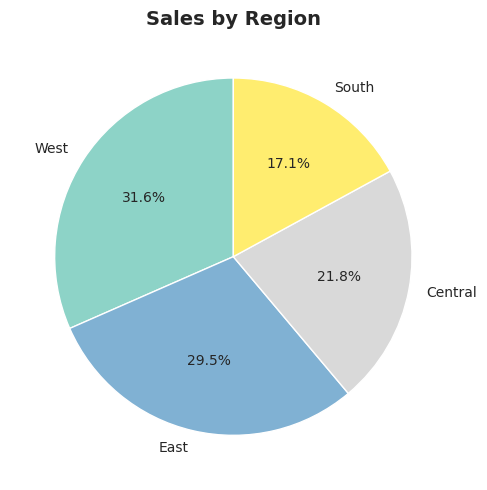

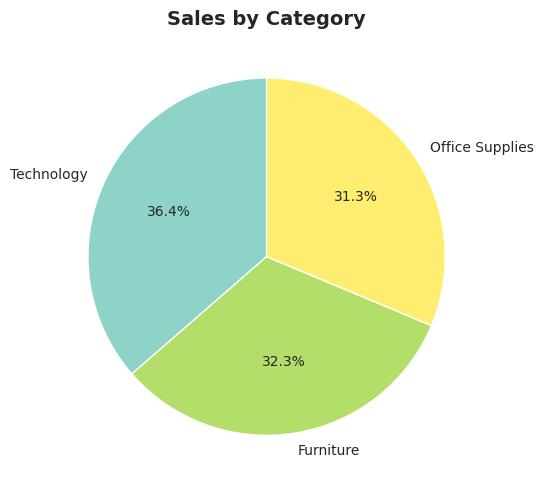

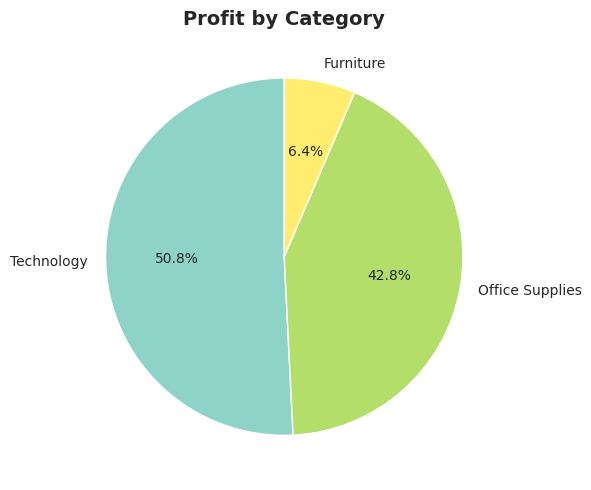

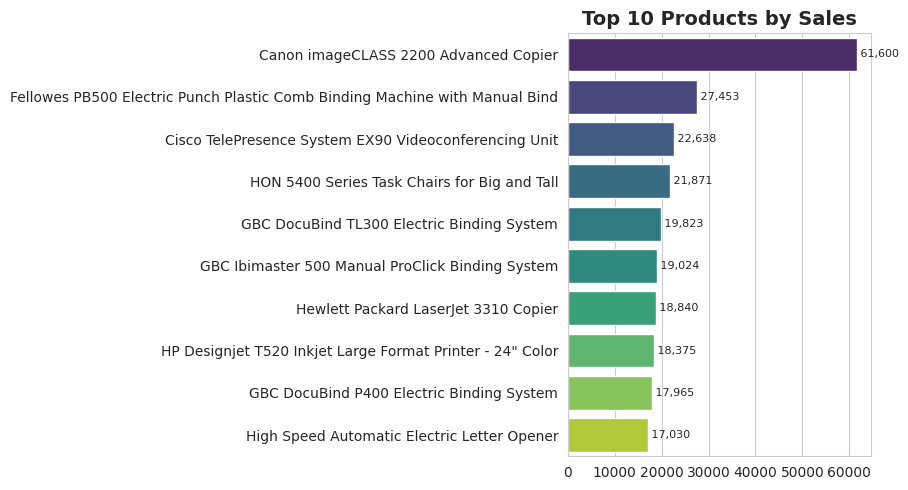

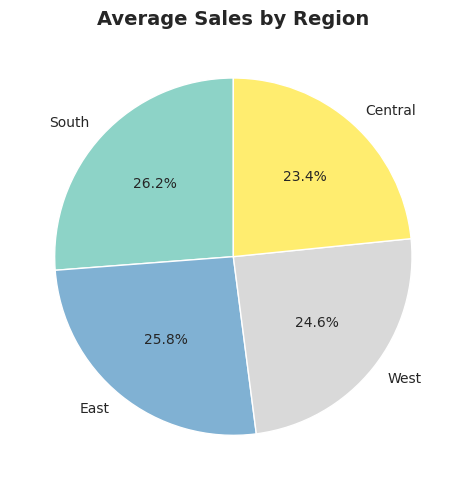

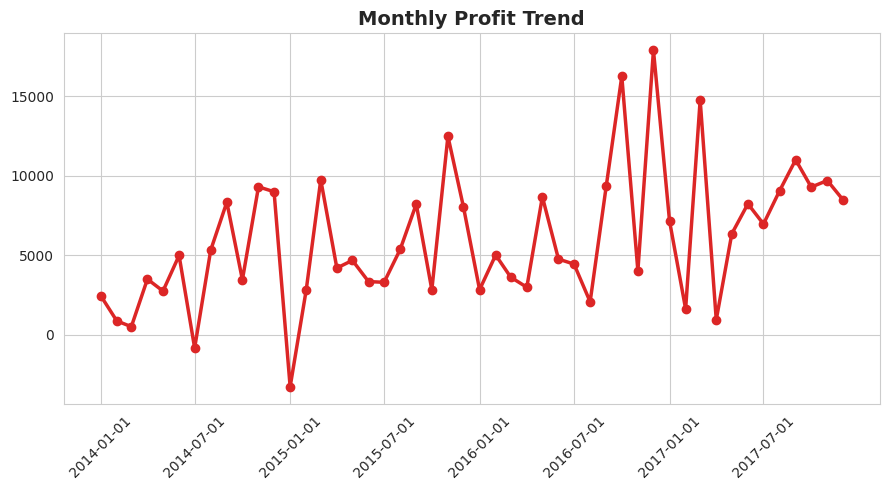

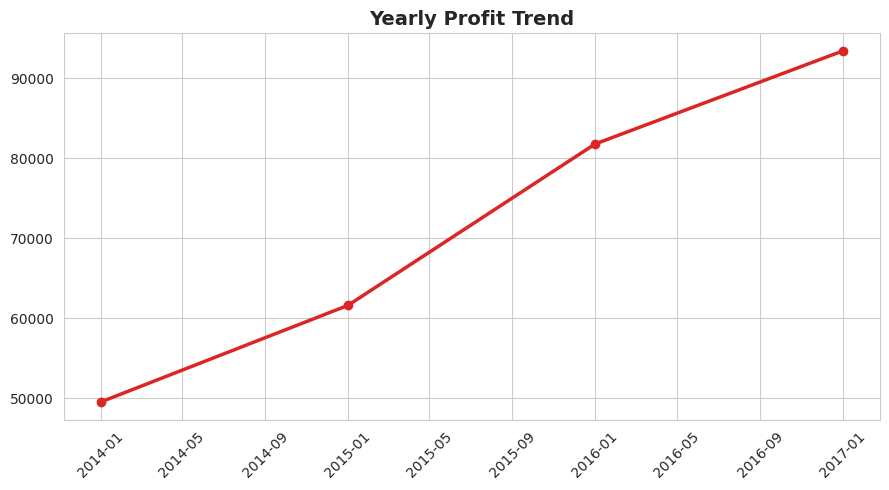

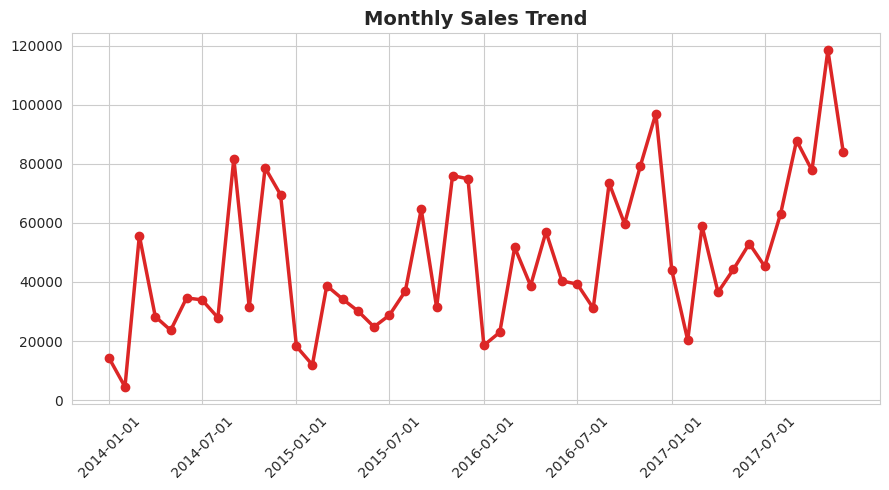

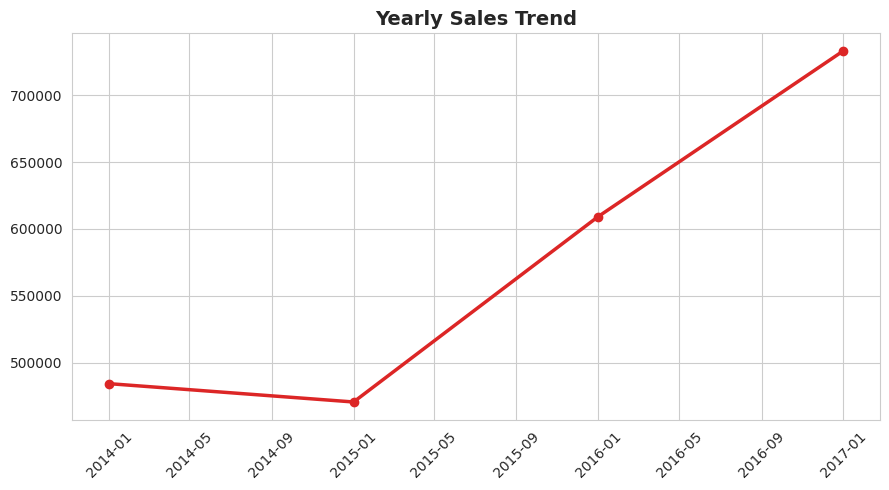

In [ ]:

# ---------------- Styling ----------------
sns.set_style("whitegrid")
plt.rcParams["axes.titleweight"] = "bold"

BAR_COLOR = "#2563eb"
LINE_COLOR = "#dc2626"

# ---------------- KPI Summary ----------------
print("\n" + "="*60)
print(f"{dataset_type.upper()} - KEY PERFORMANCE INDICATORS")
print("="*60)

for k, v in kpis.items():
    if isinstance(v, (int, float)):
        print(f"{k:<30}: {v:,.2f}")
    else:
        print(f"{k:<30}: {v}")

print("="*60)

# ---------------- Charts ----------------
for title, data in report_analysis.items():

    if data is None or len(data) == 0:
        continue

    plt.figure(figsize=(9,5))

    # -------- Time Series --------
    if isinstance(data.index, (pd.DatetimeIndex, pd.PeriodIndex)):

        x = data.index
        if isinstance(x, pd.PeriodIndex):
            x = x.to_timestamp()

        plt.plot(
            x,
            data.values,
            marker="o",
            linewidth=2.5,
            color=LINE_COLOR
        )

        if len(x) > 12:
            step = max(1, len(x)//8)
            plt.xticks(x[::step], rotation=45)
        else:
            plt.xticks(rotation=45)

    # -------- Pie Chart --------
    elif len(data) <= 5 and data.min() >= 0:

        plt.pie(
            data.values,
            labels=data.index.astype(str),
            autopct="%1.1f%%",
            startangle=90,
            colors=plt.cm.Set3(np.linspace(0,1,len(data)))
        )

    # -------- Horizontal Bar --------
    elif "top" in title.lower() or any(len(str(i)) > 12 for i in data.index):

        top_data = data.head(10)

        ax = sns.barplot(
            x=top_data.values,
            y=top_data.index.astype(str),
            hue=top_data.index.astype(str),
            palette="viridis",
            legend=False
        )

        for i, v in enumerate(top_data.values):
            ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8)

    # -------- Vertical Bar --------
    else:

        top_data = data.head(10)

        ax = sns.barplot(
            x=top_data.index.astype(str),
            y=top_data.values,
            hue=top_data.index.astype(str),
            palette="viridis",
            legend=False
        )

        plt.xticks(rotation=30)

        if len(top_data) <= 8:
            for container in ax.containers:
                ax.bar_label(container, fmt="%.0f", fontsize=8)

    plt.title(title, fontsize=14)
    plt.xlabel("")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
    plt.close()

In [ ]:
!pip install -q -U google-genai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.8/55.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 24.5 MB/s eta 0:00:00


In [ ]:
from google import genai
from google.colab import userdata

client = genai.Client(api_key=userdata.get("Saman_Gemini_API_Key"))

for model in client.models.list():
    print(model.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.1-flash-lite-image
models/gemini-3.5-flash
models/gemini-omni-flash-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
mod

In [ ]:
from google import genai
from google.colab import userdata
import json

# Gemini Client
client = genai.Client(api_key=userdata.get("Saman_Gemini_API_Key"))

# KPIs -> Text
kpi_text = "\n".join(f"- {k}: {v}" for k, v in kpis.items())

# Business Analysis -> Text
analysis_text = "\n".join(
    f"{title}: {dict(data.head(3))}"
    for title, data in report_analysis.items()
)

# Prompt
prompt = f"""
You are a senior business analyst.

Analyze ONLY the information below.

Dataset Type:
{dataset_type}

KPIs:
{kpi_text}

Business Analysis:
{analysis_text}

Return ONLY valid JSON in this format:

{{
  "executive_summary":"...",
  "key_findings":["...","...","..."],
  "insights":"...",
  "recommendations":["...","...","..."]
}}

Do not use markdown.
Do not use ```json.
Return only JSON.
"""

# Generate Response
response = client.models.generate_content(
    model="gemini-flash-latest",
    contents=prompt
)

# Parse JSON
raw = response.text.strip()

ai_report = json.loads(raw)

# Print Report
print("="*60)
print("EXECUTIVE SUMMARY")
print("="*60)
print(ai_report["executive_summary"])

print("\nKEY FINDINGS")
for item in ai_report["key_findings"]:
    print("•", item)

print("\nINSIGHTS")
print(ai_report["insights"])

print("\nRECOMMENDATIONS")
for item in ai_report["recommendations"]:
    print("•", item)

raw = response.text.strip()

if raw.startswith("```json"):
    raw = raw.replace("```json", "").replace("```", "").strip()
elif raw.startswith("```"):
    raw = raw.replace("```", "").strip()

ai_report = json.loads(raw)

EXECUTIVE SUMMARY
With total sales of $2,297,200.86 and profits of $286,397.02, the business operates at a healthy 12.47% profit margin. While overall growth trends are positive—with annual profits rising consistently from $49,543.97 in 2014 to $81,795.17 in 2016—significant profit erosion is occurring in the Furniture category, which generated $741,999.80 in sales but only $18,451.27 in profit. Technology remains the key driver of both sales ($836,154.03) and profitability ($145,454.95), led by high-performing products such as the Canon imageCLASS 2200 Advanced Copier.

KEY FINDINGS
• Category Profitability Divergence: Furniture is the second-largest category by sales ($741,999.80) but generates an extremely low profit of $18,451.27, representing a minor fraction of the profits generated by Technology ($145,454.95) and Office Supplies ($122,490.80).
• Year-over-Year Growth: Yearly sales experienced a minor contraction from 2014 ($484,247.50) to 2015 ($470,532.51) before rebounding str